# **Regularização Dinâmica: a camada _Dropout_**
<font size=3>
    
À medida que nossas arquiteturas de redes neurais crescem em complexidade e capacidade, deparamo-nos com um desafio fundamental como expandir o poder de representação de um modelo sem permitir que ele simplesmente memorize o ruído dos dados de treinamento? Nesta aula, exploraremos o **_Dropout_**, uma técnica simples e amplamente utilizadas em modelos de *Deep Learning*.

## **1. O dilema do aprendizado:**
<font size=3>
    
Durante a etapa de **treinamento e validação**, utilizamos os dados de treino para que um **otimizador** atualize os parâmetros internos do modelo (*weights* e *biases*) ao longo de sucessivas épocas. O objetivo central desse processo é minimizar a função de perda. Simultaneamente, medimos o desempenho da rede a cada época utilizando um conjunto de dados de validação, que o modelo nunca viu durante o ajuste dos pesos.

<font size=3>

O objetivo do treinamento validativo é moldar a arquitetura a fim de navegar entre dois extremos do **_underfitting_** e do **_overfitting_**:

* **_Underfitting_** ocorre quando a rede neural possui uma capacidade de representação insuficiente para aprender os padrões intrínsecos dos dados. Como resultado, o modelo apresenta um desempenho ruim tanto no conjunto de treino quanto no de validação. Para mitigar esse problema , precisamos tornar a arquitetura mais robusta, aumentando sua profundidade e largura (adicionando mais camadas e mais neurônios).

* **_Overfitting_** ocorre quando o modelo é excessivamente complexo para o problema e acaba "memorizando" o conjunto de treinamento — incluindo seus ruídos, variações estocásticas e particularidades. O sintoma clássico é uma curva de perda de treino que decresce continuamente, enquanto a perda de validação começa a subir (divergir).


### **1.1 Estratégias de mitigação do _overfitting_:**
<font size=3>

Para combater o *overfitting* e garantir a capacidade de generalização, temos algumas alternativas:
1. **Reduzir a capacidade da rede:** Podemos diminuir o número de neurônios ou de camadas ocultas. Funciona como uma analogia matemática à redução do grau de uma função polinomial: limitamos os caminhos possíveis para que o modelo não consiga memorizar pontos específicos.

2. **Regularização:** Em vez de diminuir a capacidade da rede permanentemente (o que limitaria seu teto de aprendizado para problemas muito complexos), podemos aplicar penalidades ou restrições dinâmicas. É aqui que entra a técnica **_Dropout_**:
    > Em vez de remover neurônios da arquitetura de forma definitiva, nós os desativamos temporariamente e de forma aleatória a cada iteração do treino.


## **2. O mecanismo do _Dropout_:**
<font size=3>

Quando o treinamento de uma rede neural avança sem regularização, neurônios adjacentes tendem a desenvolver uma dependência excessiva mútua para corrigir erros de previsão do gradiente. Na literatura de *Deep Learning*, chamamos isso de **co-adaptação de recursos** (*feature co-adaptation*). *Se um neurônio sempre depende do comportamento específico de outro para gerar uma boa representação, a rede se torna frágil e altamente propensa a memorizar o ruído do conjunto de treino (overfitting)*.

<font size=3>

Desenvolvido por [Srivastava et al., 2014](https://www.jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf?utm_content=buffer79b4), O _**dropout**_, durante o **treinamento**, "desliga" as ativações de neurônios de uma determinada camada de forma completamente aleatória, definindo seus valores como zero.

Deste modo, forçamos a rede a desenvolver o que podemos chamar de **"_neuroplasticidade artificial_"**. Como qualquer neurônio pode desaparecer repentinamente **a cada época**, nenhum neurônio pode confiar que seus vizinhos estarão lá para complementar sua informação. Isso força cada neurônio individual a aprender características mais robustas, independentes e generalizáveis.

<font size=3><center>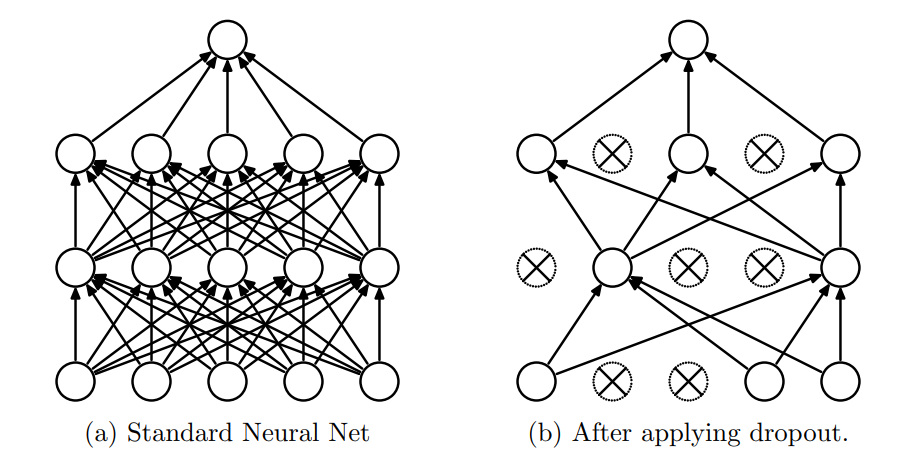</center></p><p style="text-align:center;"><em>Figura do artigo pioneiro.</em>

<font size=3>

> Na fase de **teste**, o *dropout* fica **inativo**, retornando todas as ativações dos neurônios.

### **2.1 A formulação matemática:**
<font size=3>

No fluxo de uma rede densa, a ativação da camada $l$ é descrito como
$$
    a_l^i = \sigma_l\left(W_l^{ij} a_{l-1}^j + b_l^i\right) \, .
$$

Com a inclusão do *dropout*, o processo passa a ser governado por uma distribuição de probabilidade discreta: a **Distribuição de Bernoulli**. Para cada neurônio $j$ na camada $l-1$, geramos uma variável aleatória $r_{l-1}^j$ que dita se aquele neurônio será mantido ou desligado, dado por
\begin{align}
    r_{l-1}^j &\sim \text{Bernoulli}(p) \, ,\\
    \tilde a_{l-1}^j &= \frac{r_{l-1}^j \odot a_{l-1}^j}{1-p} \, ,\\
    a_l^i &= \sigma_l\left(W_l^{ij}\,\tilde a_{l-1}^j + b_l^i\right) \, ,
\end{align}
onde:
* $p$ é a probabilidade de um neurônio ser **desativo**;
* $r_{l-1}^j$ é um vetor de máscaras binárias (contendo apenas valores $0$ e $1$) amostrado a partir da distribuição de Bernoulli;
* $\odot$ representa o elemento a elemento (element-wise);
* $1/(1-p)$ é o fator de escala. No caso de $p=0.5$, o fator de escala será 2. Se tínhamos 100 neurônios e metade foi desligada, os 50 sobreviventes têm as suas ativações multiplicadas por $2$ (**fase de treinamento**). Assim, a magnitude total esperada que sai da camada volta a ser exatamente a mesma de quando os 100 neurônios estiverem ativos (**fase de teste**).
  

In [1]:
import numpy as np
from scipy.stats import bernoulli

In [2]:
# simulando o efeito do dropout ao longo das épocas:
n_neurons = 12
p = 0.4
epochs = 3

a = np.random.randn(n_neurons)

for epoch in range(1, epochs+1):

    r = bernoulli.rvs(p, size=a.shape)

    ã = r * a

    print(f"# Época {epoch}/{epochs}:")
    print(f" r = {r}" )
    print(f" Neurônios ativos: {np.sum(r)} de {n_neurons}")
    print(f" Camada densa após dropout: {np.round(ã, 2)}\n")


# Época 1/3:
 r = [0 1 1 0 0 0 1 0 0 0 0 0]
 Neurônios ativos: 3 de 12
 Camada densa após dropout: [ 0.   -0.51 -0.57  0.   -0.   -0.    0.15  0.    0.    0.    0.   -0.  ]

# Época 2/3:
 r = [0 0 0 1 1 0 0 1 0 0 1 0]
 Neurônios ativos: 4 de 12
 Camada densa após dropout: [ 0.   -0.   -0.    0.3  -0.14 -0.    0.    0.15  0.    0.    0.44 -0.  ]

# Época 3/3:
 r = [1 0 0 1 0 0 0 0 0 0 0 0]
 Neurônios ativos: 2 de 12
 Camada densa após dropout: [ 0.37 -0.   -0.    0.3  -0.   -0.    0.    0.    0.    0.    0.   -0.  ]



### **2.2 O efeito de um "_ensemble_":**
<font size=3>

Uma das perspectivas matemáticas e teóricas mais fascinantes sobre o Dropout é que ele funciona, essencialmente, como um **Ensemble de Modelos** (um comitê ou combinação de várias redes neurais diferentes) treinado de forma implícita.

Imagine uma camada da nossa rede que possua $n$ neurônios. Como cada neurônio tem duas opções a cada passo do treino (ou ele está ativo, ou está desligado), o número total de combinações arquiteturais possíveis dentro dessa única camada é de exatamente **$2^n$ sub-redes distintas**. Se tivéssemos uma rede pequena, com apenas 10 neurônios, isso significaria $2^{10} = 1.024$ arquiteturas possíveis.

Como o sorteio do vetor $r_{l-1}^j$ acontece a cada época do treinamento, esparemos ajustando sucessivas sub-redes — que compartilham exatamente os mesmos parâmetros *weights* e *biases*.

> Ao final do treinamento, os pesos configurados na rede representam uma **média consensual e otimizada de todas as sub-redes que foram amostradas ao longo das épocas**. O *dropout* nos concede o poder preditivo e a robustez de um *ensemble* de modelos gastando o custo computacional e de memória de **uma única rede**.


## **3. Integração como API:**
<font size=3>

No Keras, o *dropout* não é configurado como um parâmetro dentro de uma camada densa, mas sim como uma **camada** ([`layers.Dropout`](https://keras.io/api/layers/regularization_layers/dropout/)). Esta camada atua diretamente sobre o vetor de ativações gerado pela camada imediatamente anterior.


In [ ]:
import keras
from keras import layers

In [ ]:
# simulando uma rede neural:

x_in = keras.Input(shape=(50,)) # Exemplo: 10 características de entrada
x = layers.Dense(200, activation='relu')(x_in)

# aplicando dropout de 40% sobre os 200 neurónios da camada anterior:
x = layers.Dropout(rate=0.4)(x)

x = layers.Dense(20, activation='relu')(x)
x_out = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=x_in, outputs=x_out)
model.summary()

## __Referência:__
<font size=3>
    
 - [Deep Learning with Python](https://books.google.com.br/books/about/Deep_Learning_with_Python.html?id=Yo3CAQAACAAJ&redir_esc=y).
   